# Experiment Showcase — Multi-Axis Benchmarking

This notebook covers all three implemented benchmarking axes and shows
how to run experiments using the config-driven pipeline.

| Axis | Options |
|------|---------|
| **P0 — Axis 3: Feature Filtering** | MT · ribo · low-expr · HB · TCR/Ig VDJ · sex-chr · Gini-min |
| **P1 — Axis 4: Feature Selection** | `expr` · `zscore` · `tfidf` · `de` · `marker_panel` · `combined` |
| **P1 — Axis 2: Input Entity** | `single_cell` · `knn_smoothed` (k=5,20,100) · `pseudobulk` |

**Sections**
1. Setup — load data, compute global metrics + ADT (once)
2. Axis 3 — Feature Filtering: what each filter removes
3. Feature Selection: gene scoring strategies + parallel protein selection
4. Single-Cell Annotation: genes + proteins → prompt → LLM → result
5. Config system — load, inspect, override, dry-run
6. Run a single experiment
7. Run multiple experiments and compare results

In [87]:
%load_ext autoreload
%autoreload 2
import os, sys, warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
load_dotenv()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import sc_annotation as sca
from sc_annotation.config import ExperimentConfig, FilterConfig, SelectionConfig, InputConfig
from sc_annotation.filtering import build_gene_mask, summarise_mask
from sc_annotation.selection import (
    compute_scores, select_genes, select_by_marker_panel, MarkerPanel,
)
from sc_annotation.smoothing import build_knn_index, get_knn_indices, compute_pseudobulk
from sc_annotation.adt import build_adt_adata, normalize_adt, get_top_proteins
from sc_annotation.pipeline import run_experiment, build_backend, ensure_global_metrics
from sc_annotation.data import load_dataset, sample_cells
from sc_annotation.global_metrics import compute_global_metrics
from sc_annotation.backends import GeminiBackend

PBMC_PATH = 'Datasets/PBMC_CiteSeqRef/pbmc_citeseq_ref_2021.h5ad'
CONFIGS_DIR = 'configs'
print('Imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


## 1. Load Dataset and Compute Global Metrics

Two parallel feature matrices are prepared once here and reused throughout:

| Modality | Normalization | Stored in |
|----------|--------------|-----------|
| RNA (33k genes) | lognorm — library-size to 10k + log1p | `adata.layers['lognorm']` |
| ADT (proteins) | CLR — center log-counts per cell around cell's own background | `adt_adata.layers['clr']` |

Population statistics (`mean_expr`, `std_expr`, `idf`) are derived from the RNA lognorm layer
and cached in `adata.var`. All downstream scoring and selection steps read from these precomputed quantities.

In [88]:
adata = load_dataset(PBMC_PATH)
print(adata)
print('\nLabel distribution (l1):')
print(adata.obs['celltype.l1'].value_counts())

AnnData object with n_obs × n_vars = 161764 × 33538
    obs: 'celltype.l1', 'celltype.l2', 'celltype.l3', 'donor', 'time', 'lane', 'Phase', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT'
    var: 'gene_symbol', 'feature_type'
    uns: 'ADT_names', 'dataset', 'source_geo'
    obsm: 'protein_counts'

Label distribution (l1):
celltype.l1
Mono       49010
CD4 T      41001
CD8 T      25469
NK         18664
B          13800
other T     6789
DC          3589
other       3442
Name: count, dtype: int64


In [89]:
%%time
compute_global_metrics(adata, n_top_hvg=2000, compute_gini=True, gini_scope='expressed', inplace=True)
print('var columns:', adata.var.columns.tolist())

INFO: Computing lognorm layer...
INFO: Computing population statistics...
INFO: Computing highly variable genes...
INFO: Computing Gini index...


Gini (expressed genes): 100%|██████████| 12016/12016 [00:17<00:00, 699.87it/s]


var columns: ['gene_symbol', 'feature_type', 'mean_expr', 'std_expr', 'pct_cells', 'idf', 'is_low_expr', 'is_hvg', 'gini']
CPU times: user 2min 32s, sys: 40.5 s, total: 3min 13s
Wall time: 1min 10s


In [90]:
%%time
_ = build_knn_index(adata, k=10, use_rep='X_pca', inplace=True)

INFO: Computing PCA embedding with 50 components...
INFO: Building kNN index with k=10 on embedding 'X_pca'...
CPU times: user 1min 55s, sys: 3.34 s, total: 1min 59s
Wall time: 25.5 s


In [91]:
pb_reference_cell_idxs = compute_pseudobulk(adata, label_col='celltype.l2')

In [92]:
# ADT — parallel to RNA lognorm setup above
adt_adata = build_adt_adata(adata)
normalize_adt(adt_adata, method='clr', inplace=True)
print(f'ADT: {adt_adata.n_obs:,} cells × {adt_adata.n_vars} proteins, CLR-normalized')
print(f'Proteins: {list(adt_adata.var_names)}')

ADT: 161,764 cells × 228 proteins, CLR-normalized
Proteins: ['CD39', 'Rat-IgG1-1', 'CD107a', 'CD62P', 'TCR-2', 'CD30', 'CD31', 'CD34', 'CD35', 'CD36', 'CD223', 'TIGIT', 'TCR-V-9', 'CD226', 'CD178', 'CD319', 'CD171', 'Siglec-8', 'CD340', 'Rat-IgG2b', 'VEGFR-3', 'CD29', 'CD62E', 'CD4-2', 'CD4-1', 'CD22', 'CD3-1', 'CD20', 'CD27', 'CD45RB', 'CD25', 'CD24', 'CD146', 'Galectin-9', 'CD142', 'CD141', 'CD294', 'Rat-IgG1-2', 'CD45RA', 'CX3CR1', 'CD56-2', 'CD56-1', 'CD45RO', 'CD303', 'GP130', 'CD253', 'CD357', 'CD11b-1', 'CD354', 'CD11b-2', 'CLEC12A', 'CD38-2', 'CD38-1', 'Folate', 'Rag-IgG2c', 'CD209', 'CD152', 'CD154', 'CD155', 'Cadherin', 'CD201', 'CD204', 'CD205', 'CD206', 'CD207', 'CD1d', 'CD284', 'CD1c', 'Podoplanin', 'CD1a', 'CD366', 'IgD', 'IgM', 'CD66a/c/e', 'CD49d', 'LOX-1', 'TIM-4', 'CD98', 'CD370', 'CD49a', 'CD44-2', 'C5L2', 'CD44-1', 'CD158e1', 'CD124', 'CD127', 'CD126', 'CD279', 'CD278', 'CD123', 'CD122', 'CD96', 'CD274', 'CD95', 'CD271', 'CD270', 'CD90', 'CD272', 'CD16', 'CD14', 'CD

## 2. Feature Filtering

Each `FilterConfig` flag independently removes a class of uninformative genes.
We compare five progressively stricter filter presets.

In [93]:
filter_presets = {
    # 'none'              : FilterConfig(exclude_mt=False, exclude_ribo=False, exclude_low_expr=False),
    # 'mt_only'           : FilterConfig(exclude_mt=True,  exclude_ribo=False, exclude_low_expr=False),
    'mt+ribo'           : FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=False),
    # 'conservative'      : FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=True),
    # 'conservative+hb'   : FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=True,
    #                                     exclude_hb=True),
    # 'conservative+tcrig': FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=True,
    #                                     exclude_hb=True, exclude_tcr_ig=True),
    'strict'            : FilterConfig(exclude_mt=True,  exclude_ribo=True,  exclude_low_expr=True,
                                        exclude_hb=True, exclude_tcr_ig=True,
                                        exclude_sex_chr=True, gini_min=0.15),
}

rows = []
for name, fc in filter_presets.items():
    mask = build_gene_mask(adata, fc)
    s = summarise_mask(adata, mask)
    rows.append({'preset': name, 'included': s['included'], **s['excluded_by']})

filter_df = pd.DataFrame(rows).set_index('preset')
print('Genes included per filter preset:')
filter_df

Genes included per filter preset:


,included,is_mt,is_ribo,is_hb,is_tcr_vdj,is_sex_chr,is_low_expr,gini_housekeeping
preset,,,,,,,,
mt+ribo,33421,13,104,0,0,2,11,106
strict,11867,13,104,10,613,19,21522,149


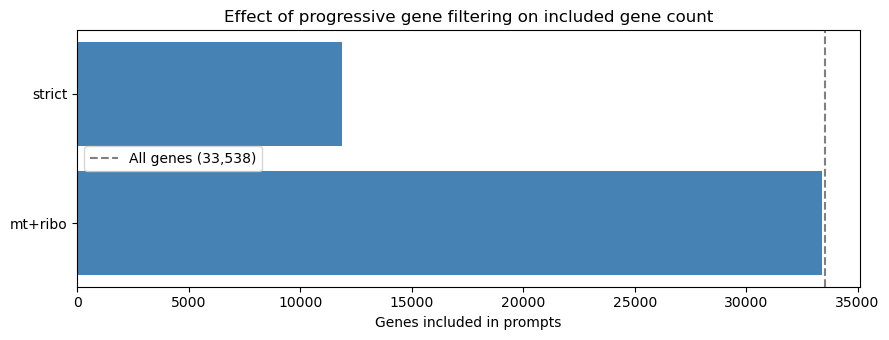

In [94]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(filter_df.index, filter_df['included'], color='steelblue')
ax.set_xlabel('Genes included in prompts')
ax.set_title('Effect of progressive gene filtering on included gene count')
ax.axvline(adata.n_vars, color='grey', linestyle='--', label=f'All genes ({adata.n_vars:,})')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Feature Selection: Genes and Proteins

Gene scoring strategies are compared side-by-side for the same input entity.
Protein (ADT) selection runs in parallel using the same `cell_indices` interface —
`get_top_proteins` averages raw counts across cells and re-applies CLR,
mirroring the pre-log mean aggregation used for RNA.

In [107]:
CELL_IDX  = np.random.choice(pb_reference_cell_idxs['HSPC'], size=1)[0]
gene_mask = build_gene_mask(adata, filter_presets['strict'])

true_l1 = adata.obs['celltype.l1'].iloc[CELL_IDX]
true_l2 = adata.obs['celltype.l2'].iloc[CELL_IDX]
true_l3 = adata.obs['celltype.l3'].iloc[CELL_IDX]
print(f'Cell {CELL_IDX} — true label: {true_l1} / {true_l2} / {true_l3}\n')

### Three different ways to define the input entity
cell_idx_single = [CELL_IDX]  # just the cell itself 

neighbor_index = build_knn_index(adata, 10, use_rep='X_pca', inplace=False)
cell_idx_10nn = get_knn_indices(CELL_IDX, neighbor_index, k=10)  # the 10 nearest neighbors of the cell

size = max(200, len(pb_reference_cell_idxs[true_l2]))
cell_idx_pb = np.random.choice(pb_reference_cell_idxs[true_l2], size=size, replace=False).tolist() + [CELL_IDX]  # random cells from the same L2 population + the cell itself

Cell 63860 — true label: other / HSPC / HSPC



In [97]:
# Venn-style overlap between strategies (top-100)
N_OVERLAP = 100
sets = {
    s: set(g for g, _ in select_genes(compute_scores(adata, CELL_INPUT, s, gene_mask), N_OVERLAP))
    for s in ['expr', 'zscore', 'tfidf']
}

print(f'Top-{N_OVERLAP} gene overlap between strategies:')
for a in ['expr', 'zscore', 'tfidf']:
    for b in ['expr', 'zscore', 'tfidf']:
        if b >= a:
            ov = len(sets[a] & sets[b])
            print(f'  {a:8s} ∩ {b:8s} = {ov}/{N_OVERLAP} ({ov/N_OVERLAP:.0%})')

Top-100 gene overlap between strategies:
  expr     ∩ expr     = 100/100 (100%)
  expr     ∩ zscore   = 9/100 (9%)
  expr     ∩ tfidf    = 22/100 (22%)
  zscore   ∩ zscore   = 100/100 (100%)
  tfidf    ∩ zscore   = 61/100 (61%)
  tfidf    ∩ tfidf    = 100/100 (100%)


In [98]:
# Parallel protein selection — same four strategies as gene scoring, same CELL_INPUT
# compute_scores(adt_adata, ..., layer='clr') is called internally by get_top_proteins,
# so expr / zscore / tfidf / de all work for proteins via the unified scoring pipeline.
N_PROT = 20
prot_sets = {
    s: set(p for p, _ in get_top_proteins(adt_adata, CELL_INPUT, n_top=N_PROT, strategy=s))
    for s in ['expr', 'zscore', 'de']
}

print(f'Top-{N_PROT} protein overlap between strategies (CELL_INPUT={len(CELL_INPUT)} cells):')
for a in ['expr', 'zscore', 'de']:
    for b in ['expr', 'zscore', 'de']:
        if b >= a:
            ov = len(prot_sets[a] & prot_sets[b])
            print(f'  {a:8s} ∩ {b:8s} = {ov}/{N_PROT} ({ov/N_PROT:.0%})')

print()
print('Top proteins by zscore:')
for name, score in get_top_proteins(adt_adata, CELL_INPUT, n_top=N_PROT, strategy='zscore'):
    print(f'  {name:<30s}  z={score:+.3f}')

Top-20 protein overlap between strategies (CELL_INPUT=51 cells):
  expr     ∩ expr     = 20/20 (100%)
  expr     ∩ zscore   = 5/20 (25%)
  zscore   ∩ zscore   = 20/20 (100%)
  de       ∩ expr     = 5/20 (25%)
  de       ∩ zscore   = 16/20 (80%)
  de       ∩ de       = 20/20 (100%)

Top proteins by zscore:
  CD34                            z=+6.001
  CD133-2                         z=+5.207
  CD117                           z=+4.957
  CD71                            z=+3.890
  CD133-1                         z=+2.944
  MERTK                           z=+1.522
  CD123                           z=+1.249
  CD275-1                         z=+1.177
  CD325                           z=+1.033
  Siglec-8                        z=+0.987
  CD138-1                         z=+0.899
  Rat-IgG1-1                      z=+0.874
  CD99                            z=+0.857
  CD110                           z=+0.830
  CD205                           z=+0.794
  CD112                           z=+0.778
  CD3

## 4. Single-Cell Annotation: Genes → Prompt → LLM

A worked example of the full per-cell pipeline for one cell:
select top genes → build prompt → call the LLM → parse cell type and reasoning.

This mirrors exactly what `run_experiment` does inside its annotation loop.

In [99]:
from sc_annotation.prompts import SYSTEM_PROMPT, build_naive_prompt, build_enriched_prompt
from sc_annotation.metrics import extract_cell_type, extract_rationale

N_TOP = 100
TISSUE = 'PBMC'

print(f'Cell {CELL_IDX}  |  true label: {true_l1} / {true_l2}')
print(f'Using top-{N_TOP} genes (strict filter, {int(gene_mask.sum()):,} included) + top-20 proteins\n')

# --- Step 1a: score and select genes ---
scores_e     = compute_scores(adata, CELL_INPUT, 'expr',   gene_mask)
scores_z     = compute_scores(adata, CELL_INPUT, 'zscore', gene_mask)
scores_tfidf = compute_scores(adata, CELL_INPUT, 'tfidf',  gene_mask)

top_genes_e     = select_genes(scores_e, N_TOP)
top_genes_z     = select_genes(scores_z, N_TOP)
top_genes_tfidf = select_genes(scores_tfidf, N_TOP)

# --- Step 1b: score and select proteins (CLR layer, zscore strategy) ---
# compute_scores(adt_adata, ..., layer='clr') — same pipeline, different modality
proteins = get_top_proteins(adt_adata, CELL_INPUT, n_top=20, strategy='zscore')
print(f'Top proteins (zscore): {[p for p, _ in proteins]}')

Cell 52144  |  true label: other / HSPC
Using top-100 genes (strict filter, 11,867 included) + top-20 proteins

Top proteins (zscore): ['CD34', 'CD133-2', 'CD117', 'CD71', 'CD133-1', 'MERTK', 'CD123', 'CD275-1', 'CD325', 'Siglec-8', 'CD138-1', 'Rat-IgG1-1', 'CD99', 'CD110', 'CD205', 'CD112', 'CD370', 'CD324', 'CD357', 'CD194']


In [ ]:
# --- Step 2: call the LLM — genes + proteins for each scoring strategy ---
backend = GeminiBackend(
    model='gemini-2.5-flash',
    temperature=1.0,
    api_key=os.environ['GOOGLE_API_KEY'])

print(f'True label : {true_l1} / {true_l2}')
for name, tg in {
        'expr': top_genes_e,
        'zscore': top_genes_z,
        'tfidf': top_genes_tfidf
    }.items():
    prompt = build_naive_prompt(tg, proteins=proteins, tissue=TISSUE)
    response = backend.complete(prompt, system_message=SYSTEM_PROMPT)

    cell_type  = extract_cell_type(response)
    rationale  = extract_rationale(response)
    print(f"=============={name}==================")
    print(f'Predicted  : {cell_type}')
    print(f'Rationale  : {rationale}')

True label : other / HSPC
==============expr==================
Predicted  : Hematopoietic Stem and Progenitor Cell (HSPC)
Rationale  : Strong co-expression of CD34, CD133, and CD117 surface proteins unequivocally identifies this cell as an HSPC. High CD71 and CDK6 expression are consistent with actively proliferating progenitor cells.
==============zscore==================
Predicted  : Hematopoietic Stem and Progenitor Cell (HSPC)
Rationale  : High expression of CD34, CD133, and CD117 proteins are canonical markers for HSPCs. Gene expression of MYB, SOX4, FLT3, ETV6, ALDH1A1, and AKR1C3 further supports an undifferentiated hematopoietic progenitor state with strong proliferative potential.
==============tfidf==================
Predicted  : Hematopoietic Stem and Progenitor Cell (HSPC)
Rationale  : Strong co-expression of CD34, CD133, and CD117 proteins are definitive markers for HSPCs. Genes like SOX4, MYB, STMN1, LMO4, BCL11A, and ALDH1A1 further support a proliferating, undifferentia

In [101]:
# --- Step 3: combined prompt — all three gene lists + proteins ---
N_TOP = 100

prompt_combined = build_enriched_prompt(
    genes_by_expr=select_genes(scores_e, N_TOP),
    genes_by_zscore=select_genes(scores_z, N_TOP),
    genes_by_tfidf=select_genes(scores_tfidf, N_TOP),
    proteins=proteins,
    tissue=TISSUE,
)

response_combined = backend.complete(prompt_combined, system_message=SYSTEM_PROMPT)

print('=== combined prompt (genes + proteins) ===')
print(f'  Predicted: {extract_cell_type(response_combined)}')
print(f'  Rationale: {extract_rationale(response_combined)}')

=== combined prompt (genes + proteins) ===
  Predicted: Hematopoietic Stem/Progenitor Cell
  Rationale: This cell strongly expresses key surface markers like CD34, CD133, CD117 (KIT), and CD71, which are canonical for hematopoietic stem and progenitor cells (HSPCs). Additionally, highly specific gene expression includes FLT3, MYB, SOX4, CDK6, and SPINK2, all crucial regulators of HSPC proliferation, survival, and differentiation.


## 5. Stage-2 Refinement: Confirm / Polish Stage-1 Annotations via LLM Gene Programs

Stage-1 gives a coarse annotation (e.g. "CD8 T cell").
Stage-2 uses the stage-1 output as a starting point — not a hard constraint — and
refines it to the specific subtype, or corrects it when the evidence disagrees.

```
Stage-1 label  ──►  LLM: "what are the subtypes of X,
                          and what cell types are often confused with X?"
                          ↓ JSON gene programs
                    Score cell vs. each program (mean z-score)
                          ↓ pathway scores
                    LLM: genes + proteins + pathway scores
                          → confirm or correct stage-1, name specific subtype
```

**Key design choices**
- Programs are queried **per stage-1 label** and cached, so novel cell types work
  without any hardcoding.
- The query asks for **confused neighbors** (e.g. NK alongside CD8 T), so pathway
  scoring can detect outright misclassifications.
- `thinking_budget=0` is set for the JSON query call: Gemini 2.5 Flash spends
  thousands of thinking tokens before writing a single visible token, which exhausts
  small `max_output_tokens` budgets. Disabling thinking is appropriate for factual
  gene-list lookup.

In [102]:
from sc_annotation.stage2 import (
    make_gemini_json_caller,
    query_subtype_programs,
    filter_programs_to_panel,
    score_gene_programs,
    build_stage2_prompt,
)

# JSON caller for program queries — thinking_budget=0 keeps the full output budget
# for the actual JSON payload (see section header for explanation).
json_caller = make_gemini_json_caller(
    model='gemini-2.5-flash',
    api_key=os.environ['GOOGLE_API_KEY'],
    max_output_tokens=25600,
    thinking_budget=0,
)

# Separate backend for stage-2 reasoning (lower temperature = more deterministic)
stage2_backend = GeminiBackend(
    model='gemini-2.5-flash',
    temperature=0.0,
    api_key=os.environ['GOOGLE_API_KEY'])

print(f"Stage-2 helpers loaded.")

Stage-2 helpers loaded.


In [103]:
# ── Demo: single cell from Section 4 (CD8 TCM) ──────────────────────────────
stage1_label_demo    = extract_cell_type(response_combined)
stage1_reasoning_demo = extract_rationale(response_combined)
print(f"Stage-1 label   : '{stage1_label_demo}'")
print(f"Stage-1 reasoning: {stage1_reasoning_demo[:120]}...")
print(f"True label      : {true_l1} / {true_l2}\n")

raw_programs_demo = query_subtype_programs(
    stage1_label_demo, json_caller, tissue=TISSUE,
    stage1_reasoning=stage1_reasoning_demo,
)
programs_demo = filter_programs_to_panel(raw_programs_demo, adata)

print(f"Programs returned ({len(raw_programs_demo)} subtypes/types):\n")
for subtype, info in raw_programs_demo.items():
    n_found = len(programs_demo[subtype])
    n_total = len(info['genes'])
    print(f"  {subtype:<27s} {n_found:2d}/{n_total} in panel   {info['description'][:55]}")


Stage-1 label   : 'Hematopoietic Stem/Progenitor Cell'
Stage-1 reasoning: This cell strongly expresses key surface markers like CD34, CD133, CD117 (KIT), and CD71, which are canonical for hemato...
True label      : other / HSPC

Programs returned (7 subtypes/types):

  Hematopoietic Stem Cell (HSC) 36/40 in panel   Quiescent, multipotent cells capable of self-renewal an
  Multipotent Progenitor (MPP) 31/42 in panel   Actively proliferating progenitors with reduced self-re
  Common Myeloid Progenitor (CMP) 17/46 in panel   Progenitors committed to myeloid lineages, characterize
  Common Lymphoid Progenitor (CLP) 34/44 in panel   Progenitors committed to lymphoid lineages, marked by C
  Erythroid Progenitor        16/49 in panel   Progenitors committed to the erythroid lineage, charact
  Megakaryocyte-Erythroid Progenitor (MEP) 17/51 in panel   Bipotential progenitors giving rise to megakaryocytes a
  Myeloid Dendritic Cell Progenitor (MDP) 25/51 in panel   Progenitors committed to myel

In [104]:
# Scoring method — three options:
#   'mean_z'  : mean z-score of program genes (simple, no background correction)
#   'tirosh'  : mean_z(program) − mean_z(background), where background genes are
#               sampled from the same expression-level bins as the program genes.
#               Replicates Scanpy score_genes (Tirosh 2016); community standard for
#               cell-type annotation.
#   'ucell'   : normalised Mann-Whitney U on per-cell gene ranks → score ∈ [0, 1].
#               Rank-based, dropout-robust; best per 2024 benchmark (Massimo et al.).

SCORE_METHOD = 'tirosh'

pw_demo = score_gene_programs(adata, CELL_INPUT, programs_demo, gene_mask, method=SCORE_METHOD)

print(f"\nPathway scores  [{SCORE_METHOD}]:\n")
for subtype, score in sorted(pw_demo.items(), key=lambda x: -x[1] if np.isfinite(x[1]) else -999):
    if np.isfinite(score):
        bar = '█' * max(0, int((score + 0.5) * 6)) if SCORE_METHOD != 'ucell' \
              else '█' * int(score * 15)
        print(f"  {subtype:<27s}: {score:+.3f}  {bar}")
    else:
        print(f"  {subtype:<27s}: n/a  (< 3 scoreable genes)")

s2_prompt_demo = build_stage2_prompt(
    stage1_label_demo,
    pw_demo,
    stage1_reasoning=stage1_reasoning_demo,
    genes_by_expr=top_genes_e,
    genes_by_zscore=top_genes_z,
    genes_by_tfidf=top_genes_tfidf,
    proteins=proteins,
    tissue=TISSUE,
)
s2_resp_demo = stage2_backend.complete(s2_prompt_demo, system_message=SYSTEM_PROMPT)

print(f"\n{'─'*55}")
print(f"True      : {true_l2}")
print(f"Stage-1   : {stage1_label_demo}")
print(f"Stage-2   : {extract_cell_type(s2_resp_demo)}")
print(f"Rationale : {extract_rationale(s2_resp_demo)}")



Pathway scores  [tirosh]:

  Multipotent Progenitor (MPP): +1.129  █████████
  Hematopoietic Stem Cell (HSC): +1.064  █████████
  Common Myeloid Progenitor (CMP): +0.121  ███
  Megakaryocyte-Erythroid Progenitor (MEP): +0.002  ███
  Erythroid Progenitor       : -0.049  ██
  Myeloid Dendritic Cell Progenitor (MDP): -0.089  ██
  Common Lymphoid Progenitor (CLP): -0.114  ██

───────────────────────────────────────────────────────
True      : HSPC
Stage-1   : Hematopoietic Stem/Progenitor Cell
Stage-2   : Multipotent Progenitor (MPP)
Rationale : This cell exhibits canonical HSPC markers (CD34, CD133, CD117, CD71) and key progenitor genes (SPINK2, MYB, SOX4, CDK6, MSI2). Pathway analysis strongly supports a multipotent state, with the highest score for Multipotent Progenitor, slightly exceeding Hematopoietic Stem Cell, indicating a highly proliferative and multipotent, yet slightly more committed, progenitor.


## Quick Reference

### CLI
```bash
# Dry run (validate config, no API calls)
python run_experiment.py configs/pbmc_l1_zscore_gemini.yaml --dry-run

# Run with override
python run_experiment.py configs/pbmc_l1_knn_k20.yaml --n-per-class 10 --results-dir my_results

# All configs
for f in configs/pbmc_l1_*.yaml; do
    python run_experiment.py $f --n-per-class 5
done
```

### Available configs
| File | Axis 2 | Axis 4 | Notes |
|------|--------|--------|-------|
| `pbmc_l1_baseline.yaml`     | single_cell | expr     | Simplest baseline |
| `pbmc_l1_zscore_gemini.yaml`| single_cell | zscore   | Default recommended |
| `pbmc_l1_tfidf.yaml`        | single_cell | tfidf    | Cell-rarity weighted |
| `pbmc_l1_combined.yaml`     | single_cell | combined | Dual expr+zscore prompt |
| `pbmc_l1_knn_k20.yaml`      | knn_k=20   | zscore   | Smoothed input |
| `pbmc_l1_pseudobulk.yaml`   | pseudobulk  | zscore   | Upper bound |
| `pbmc_l1_marker_panel.yaml` | single_cell | marker_panel | Structured markers |

### Extending
- **New filter**: add field to `FilterConfig` → logic in `filtering.build_gene_mask`
- **New strategy**: add `select_by_*` to `selection.py` → wire in `pipeline._select_genes`
- **New backend**: subclass `LLMBackend` → register in `pipeline.build_backend`
- **New prompt style**: add function to `prompts.py` → wire in `pipeline._build_prompt`